# Paper supplementary / extended data figures

Notebook companion to `paper_figure.ipynb`. Each section produces one
supplementary / extended-data figure tied to a specific paragraph in the
manuscript.

| Section | Figure file | Paragraph claim |
|---|---|---|
| 1 | `FigE_organ_young_vs_old_effect.{pdf,svg,png}` | Para 3 S3 — organ-wise Young vs Old effect size with CI + sample-level variability (motivates organ- and cell-type-level analysis over a single whole-body map) |
| 2 | `FigS_composition_control_5organs.{pdf,svg,png}` | Para 4 S3 — 5-organ composition control (Colon Epi > Mye reversal not explained by %epithelial; Stomach with same %myeloid does not reverse) |
| 3 | `FigS_trait_organ_epi_vs_mye_matrix.{pdf,svg,png}` | Para 4 S4 corrected — matrix of 8 traits × 8 organs (Epi−Mye logp). AD-specificity = "Colon is the SOLE Epi-dominant organ" holds only for AD & MS; PD/T2D Epi-dominant in 6 organs |
| 4 | `FigS_perm_endocytic_colon.{pdf,svg,png}` | Para 5 S2 — permutation null distribution for endocytic-trafficking AD gene set in Colon (k=7 from 55-gene universe, N=100k permutations, observed mean PCC vs null) |
| 5 | `FigS_coloc_sig_vs_full.{pdf,svg,png}` | Para 5 S4 — sig-only vs full-summary coloc-ABF: PICALM/ADAM10 PP.H4 collapses from ~0.85 to ~0 under full-summary; only CR1|Sigmoid (0.99) survives |

Add new sections below as needed; the setup cell loads everything required.


## Setup


In [1]:
# === Setup — paper_figure_supp.ipynb ===
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
warnings.filterwarnings('ignore')

%matplotlib inline

BASE = '..'                      # repo root (notebook lives in notebooks/)
RES  = os.path.join(BASE, 'results')
DATA = os.path.join(BASE, 'data')
FIG  = os.path.join(BASE, 'figures')
os.makedirs(FIG, exist_ok=True)

import omicverse as ov
ov.style()
LEGEND_FS, TICK_FS, LABEL_FS, TITLE_FS, TEXT_FS = 11, 12, 13, 13, 11

def save_panel(fig, name, dpi=300):
    for ext in ('pdf', 'png', 'svg'):
        fig.savefig(os.path.join(FIG, f'{name}.{ext}'), bbox_inches='tight', dpi=dpi)
    print(f'  saved -> {name}.{{pdf,png,svg}}')

print('setup OK')


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

setup OK


## Extended Data Fig E1 — per-organ Young vs Old effect size


sample-level rows: 103  (organs=15)
          organ  effect  ci_lo  ci_hi  n_young  n_old  p_welch
0   Bone_Marrow  -0.318 -1.877  1.241        2      4    0.310
1        Spleen  -0.026 -0.605  0.553        3      4    0.911
2         Ileum   0.244 -0.131  0.619        2      4    0.145
3           BAT   0.496 -1.804  2.796        3      5    0.568
4         Colon   0.531 -0.648  1.711        3      5    0.303
5         Heart   0.535 -0.560  1.630        4      5    0.270
6        Muscle   0.646 -0.487  1.779        3      5    0.206
7       Stomach   0.705 -0.844  2.255        2      3    0.197
8          Lung   0.797 -1.077  2.672        4      5    0.339
9        Kidney   0.937 -0.646  2.519        4      5    0.204
10        Liver   1.059 -0.803  2.922        4      5    0.220
11        Brain   1.580 -1.573  4.734        4      4    0.219
12     Pancreas     NaN    NaN    NaN        1      3      NaN
13         Skin     NaN    NaN    NaN        1      2      NaN
14       Thymus    

  saved -> FigE_organ_young_vs_old_effect.{pdf,png,svg}


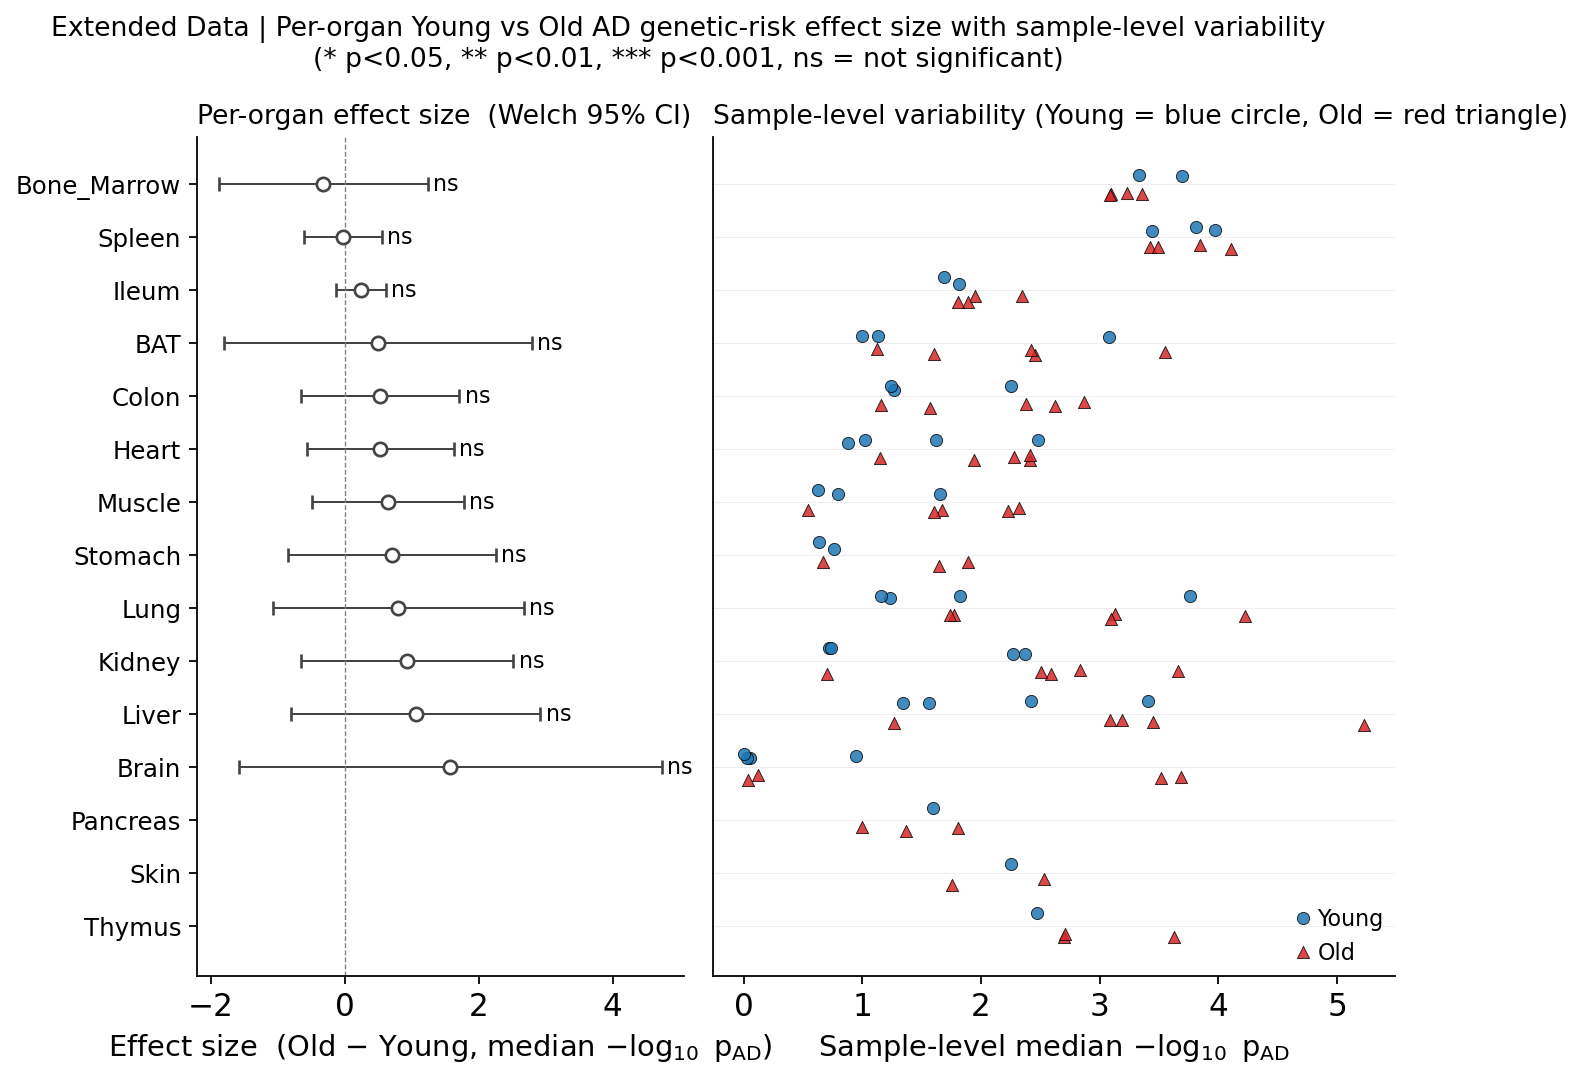


Significant organs (Welch p < 0.05):
  (none — confidence intervals overlap zero in every organ;
   per-organ sample sizes are small and Old-Young differences are
   noisy at the sample-median level)


In [2]:
# === Extended Data Fig | Per-organ Young vs Old AD genetic-risk effect size ===
# Self-contained: reads precomputed sample-level medians from results/.
# To regenerate the input CSV from the full h5ad, run:
#   python scripts/merge_age_h5ad.py    # builds data/age_merged/*.h5ad (5.5 GB)
#   python -c "import scanpy as sc, pandas as pd, numpy as np; \
#       a = sc.read_h5ad('data/age_merged/age_all_organs_all_traits.h5ad'); \
#       o = a.obs[['organ','age_months','sample','p_AD']].dropna(); \
#       o['logp'] = -np.log10(pd.to_numeric(o['p_AD'], errors='coerce').clip(1e-30)); \
#       o['age_group'] = np.where(o['age_months']<=6,'Young', np.where(o['age_months']>=18,'Old','Mid')); \
#       o.groupby(['organ','age_group','age_months','sample'])['logp'].median().reset_index() \
#         .rename(columns={'logp':'sample_median_logp'}) \
#         .to_csv('results/age_sample_medians_per_organ.csv', index=False)"
#
# Supports Paragraph 3 S3:
#   "age-resolved maps showed broad changes in spatial genetic-risk patterns
#    across organs, motivating an organ- and cell-type-level analysis rather
#    than interpretation from a single whole-body risk map alone."

samp_all = pd.read_csv(f'{RES}/age_sample_medians_per_organ.csv')
samp = samp_all[samp_all['age_group'].isin(['Young','Old'])].copy()
print(f'sample-level rows: {len(samp)}  (organs={samp["organ"].nunique()})')

# Effect size + 95% CI per organ via Welch t-test
rows = []
for organ, g in samp.groupby('organ', observed=True):
    y = g.loc[g['age_group']=='Young', 'sample_median_logp'].values
    o = g.loc[g['age_group']=='Old',   'sample_median_logp'].values
    if len(y) < 2 or len(o) < 2:
        rows.append({'organ': organ, 'effect': np.nan, 'ci_lo': np.nan,
                     'ci_hi': np.nan, 'n_young': len(y), 'n_old': len(o),
                     'p_welch': np.nan})
        continue
    effect = o.mean() - y.mean()
    s2y, s2o = y.var(ddof=1), o.var(ddof=1)
    se = np.sqrt(s2y/len(y) + s2o/len(o))
    df_w = (s2y/len(y) + s2o/len(o))**2 / (
        (s2y/len(y))**2/(len(y)-1) + (s2o/len(o))**2/(len(o)-1))
    tcrit = stats.t.ppf(0.975, df=df_w)
    ci_lo, ci_hi = effect - tcrit*se, effect + tcrit*se
    _, p = stats.ttest_ind(o, y, equal_var=False)
    rows.append({'organ': organ, 'effect': effect, 'ci_lo': ci_lo,
                 'ci_hi': ci_hi, 'n_young': len(y), 'n_old': len(o),
                 'p_welch': p})
eff = (pd.DataFrame(rows)
         .sort_values('effect', ascending=True, na_position='last')
         .reset_index(drop=True))
print(eff.round(3))

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(9.6, max(3.5, 0.36*len(eff)+1.5)),
    gridspec_kw={'width_ratios': [1.0, 1.4], 'wspace': 0.05},
    sharey=True,
)
y_pos = np.arange(len(eff))

# --- Left: forest ---
finite = eff['effect'].notna()
axL.errorbar(eff.loc[finite,'effect'], y_pos[finite],
             xerr=[eff.loc[finite,'effect'] - eff.loc[finite,'ci_lo'],
                   eff.loc[finite,'ci_hi'] - eff.loc[finite,'effect']],
             fmt='o', color='#444', ecolor='#444', capsize=3, lw=0.9, ms=6,
             markerfacecolor='white', markeredgewidth=1.2)
axL.axvline(0, color='grey', lw=0.6, ls='--')
axL.set_yticks(y_pos)
axL.set_yticklabels(eff['organ'].values, fontsize=TICK_FS-1)
axL.set_xlabel(r'Effect size  (Old $-$ Young, median $-\log_{10}$ p$_{\rm AD}$)',
               fontsize=LABEL_FS)
axL.invert_yaxis()
axL.spines['top'].set_visible(False); axL.spines['right'].set_visible(False)
for i, (p, ci_hi) in enumerate(zip(eff['p_welch'], eff['ci_hi'])):
    if pd.isna(p): continue
    star = ('***' if p < 0.001 else
            '**'  if p < 0.01  else
            '*'   if p < 0.05  else 'ns')
    x_at = ci_hi + 0.08 if pd.notna(ci_hi) else 0
    axL.text(x_at, i, star, va='center', ha='left',
             fontsize=TEXT_FS-1, color='black')
axL.set_title('Per-organ effect size  (Welch 95% CI)',
              fontsize=TITLE_FS-1, loc='left')

# --- Right: sample dots ---
np.random.seed(0)
for i, organ in enumerate(eff['organ'].values):
    for grp, color, marker, jitter in [
        ('Young', '#1f77b4', 'o', -0.18),
        ('Old',   '#d62728', '^', +0.18),
    ]:
        vals = samp.loc[(samp['organ']==organ) & (samp['age_group']==grp),
                        'sample_median_logp'].values
        if len(vals) == 0: continue
        ys = i + jitter + (np.random.rand(len(vals)) - 0.5) * 0.15
        axR.scatter(vals, ys, color=color, marker=marker, s=30,
                    edgecolor='black', lw=0.4, alpha=0.85,
                    label=grp if i == 0 else None)
axR.set_xlabel(r'Sample-level median $-\log_{10}$ p$_{\rm AD}$',
               fontsize=LABEL_FS)
axR.set_title('Sample-level variability (Young = blue circle, Old = red triangle)',
              fontsize=TITLE_FS-1, loc='left')
axR.spines['top'].set_visible(False); axR.spines['right'].set_visible(False)
axR.tick_params(left=False, labelleft=False)
axR.legend(loc='lower right', frameon=False, fontsize=LEGEND_FS-1)
for i in range(len(eff)):
    axR.axhline(i, color='#eeeeee', lw=0.5, zorder=0)

fig.suptitle('Extended Data | Per-organ Young vs Old AD genetic-risk '
             'effect size with sample-level variability\n'
             '(* p<0.05, ** p<0.01, *** p<0.001, ns = not significant)',
             fontsize=TITLE_FS-1, y=1.02)
plt.tight_layout()
save_panel(fig, 'FigE_organ_young_vs_old_effect')
plt.show()

print('\nSignificant organs (Welch p < 0.05):')
sig = eff[eff['p_welch'] < 0.05].sort_values('effect', ascending=False)
if len(sig) == 0:
    print('  (none — confidence intervals overlap zero in every organ;\n'
          '   per-organ sample sizes are small and Old-Young differences are\n'
          '   noisy at the sample-median level)')
else:
    for _, r in sig.iterrows():
        direction = 'Old > Young' if r["effect"] > 0 else 'Young > Old'
        print(f'  {r["organ"]:<14}  Δ={r["effect"]:+.2f}  '
              f'[{r["ci_lo"]:+.2f}, {r["ci_hi"]:+.2f}]  p={r["p_welch"]:.3g}  '
              f'{direction}')


## Supplementary Fig — Composition control across 5 organs (Para 4 S3)


     organ  n_total_spots  n_myeloid  pct_myeloid  n_epithelial  \
0    Brain          72929      25836        35.43           138   
1     Lung          75282      22340        29.68         17661   
2    Liver          58149       6490        11.16         40820   
3  Stomach          74115       1771         2.39          4057   
4    Colon          70198       1755         2.50         42746   

   pct_epithelial  myeloid_best_logp  epithelial_best_logp  epi_minus_mye_logp  
0            0.19               8.36                  0.04               -8.32  
1           23.46               9.11                  5.57               -3.54  
2           70.20               8.06                  4.92               -3.13  
3            5.47               5.40                  1.60               -3.81  
4           60.89               4.42                  6.33                1.91  


  saved -> FigS_composition_control_5organs.{pdf,png,svg}


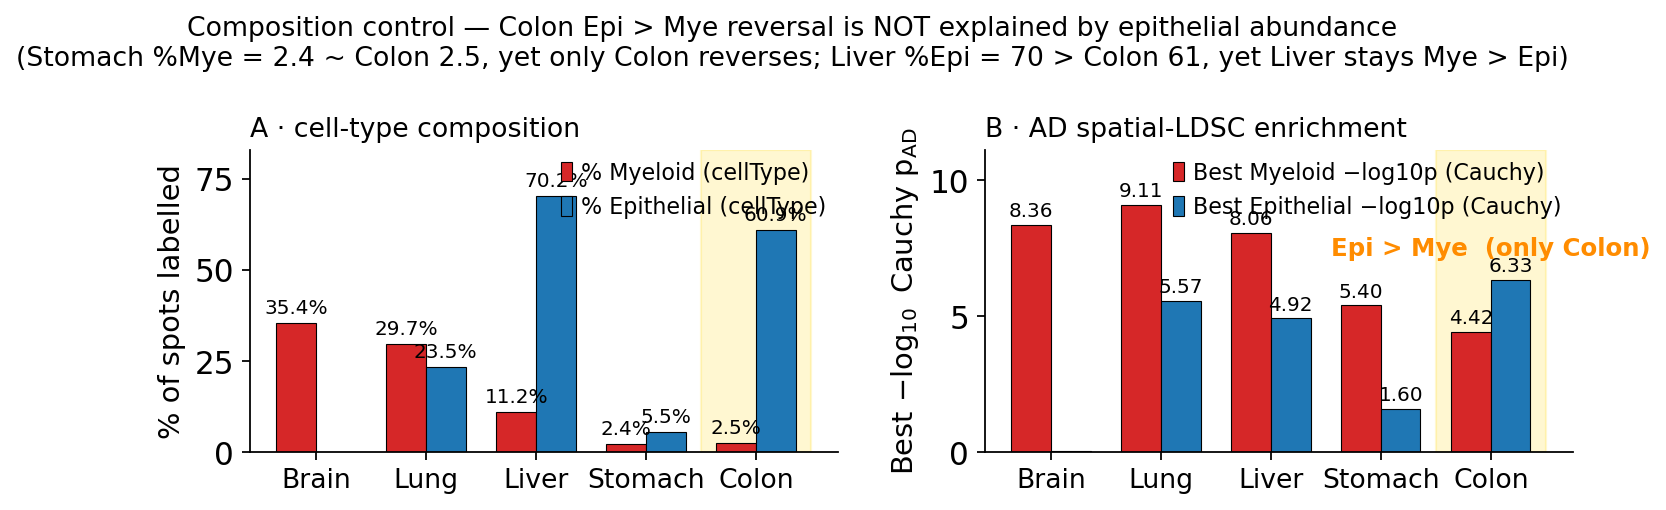


Key contrasts:
  Colon   vs Stomach (similar %Myeloid): Colon %Mye=2.5 vs Stomach 2.4 — Colon Epi/Mye=6.33/4.42 (REVERSED); Stomach 1.60/5.40 (not)
  Colon   vs Liver  (similar %Epithelial): Colon %Epi=60.9 vs Liver 70.2 — Liver Epi/Mye=4.92/8.06 (not reversed)


In [3]:
# === Supplementary Fig | Composition control across 5 organs ===
# Side-by-side 2-panel chart for Brain, Lung, Liver, Stomach, Colon:
#   Left  — composition fractions (%myeloid vs %epithelial) from cellType labels
#   Right — best -log10 Cauchy p_AD per class (myeloid vs epithelial)
# Demonstrates that the Colon Epi > Mye reversal is NOT a generic consequence
# of epithelial abundance:
#   - Liver has higher %epithelial (70%) than Colon (61%) but still Mye > Epi.
#   - Stomach has the same %myeloid (2.4%) as Colon (2.5%) but still Mye > Epi.
# → only Colon shows the qualitative reversal.
#
# Supports Paragraph 4 S3.

comp = pd.read_csv(f'{RES}/composition_control_5organs.csv')
# Order: keep paragraph order Brain, Lung, Liver, Stomach, Colon
ORDER = ['Brain','Lung','Liver','Stomach','Colon']
comp = comp.set_index('organ').loc[ORDER].reset_index()
print(comp.round(2))

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(10.6, 3),
    gridspec_kw={'wspace': 0.25},
)
x = np.arange(len(comp)); w = 0.36
MYE_C, EPI_C = '#d62728', '#1f77b4'

# --- Left: composition fractions ---
b1 = axL.bar(x - w/2, comp['pct_myeloid'],    w, color=MYE_C,
             edgecolor='black', lw=0.5, label='% Myeloid (cellType)')
b2 = axL.bar(x + w/2, comp['pct_epithelial'], w, color=EPI_C,
             edgecolor='black', lw=0.5, label='% Epithelial (cellType)')
for bars in (b1, b2):
    for b in bars:
        h = b.get_height()
        if h > 0.3:
            axL.text(b.get_x() + b.get_width()/2, h + 1.5, f'{h:.1f}%',
                     ha='center', va='bottom', fontsize=TEXT_FS-2)
# Highlight Colon column
if 'Colon' in comp['organ'].values:
    ci = list(comp['organ']).index('Colon')
    axL.axvspan(ci - 0.5, ci + 0.5, color='gold', alpha=0.18, zorder=0)
axL.set_xticks(x); axL.set_xticklabels(comp['organ'], fontsize=TICK_FS)
axL.set_ylabel('% of spots labelled', fontsize=LABEL_FS)
axL.set_title('A · cell-type composition',
              fontsize=TITLE_FS-1, loc='left')
axL.legend(loc='upper right', frameon=False, fontsize=LEGEND_FS-1)
axL.spines['top'].set_visible(False); axL.spines['right'].set_visible(False)
axL.set_ylim(0, max(comp['pct_myeloid'].max(), comp['pct_epithelial'].max()) * 1.18)

# --- Right: enrichment scores ---
b3 = axR.bar(x - w/2, comp['myeloid_best_logp'],    w, color=MYE_C,
             edgecolor='black', lw=0.5, label='Best Myeloid −log10p (Cauchy)')
b4 = axR.bar(x + w/2, comp['epithelial_best_logp'], w, color=EPI_C,
             edgecolor='black', lw=0.5, label='Best Epithelial −log10p (Cauchy)')
for bars in (b3, b4):
    for b in bars:
        h = b.get_height()
        if h > 0.05:
            axR.text(b.get_x() + b.get_width()/2, h + 0.15, f'{h:.2f}',
                     ha='center', va='bottom', fontsize=TEXT_FS-2)
# Highlight Colon
if 'Colon' in comp['organ'].values:
    ci = list(comp['organ']).index('Colon')
    axR.axvspan(ci - 0.5, ci + 0.5, color='gold', alpha=0.18, zorder=0)
    y_top = max(comp.loc[ci,'myeloid_best_logp'], comp.loc[ci,'epithelial_best_logp']) + 0.9
    axR.annotate('Epi > Mye  (only Colon)', xy=(ci, y_top), ha='center',
                 fontsize=TEXT_FS, fontweight='bold', color='darkorange')
axR.set_xticks(x); axR.set_xticklabels(comp['organ'], fontsize=TICK_FS)
axR.set_ylabel(r'Best $-\log_{10}$ Cauchy p$_{\rm AD}$', fontsize=LABEL_FS)
axR.set_title('B · AD spatial-LDSC enrichment',
              fontsize=TITLE_FS-1, loc='left')
axR.legend(loc='upper right', frameon=False, fontsize=LEGEND_FS-1)
axR.spines['top'].set_visible(False); axR.spines['right'].set_visible(False)
axR.set_ylim(0, max(comp['myeloid_best_logp'].max(),
                    comp['epithelial_best_logp'].max()) * 1.22)

plt.subplots_adjust(top=0.78)
fig.suptitle('Composition control — Colon Epi > Mye reversal '
             'is NOT explained by epithelial abundance\n'
             '(Stomach %Mye = 2.4 ~ Colon 2.5, yet only Colon reverses; '
             'Liver %Epi = 70 > Colon 61, yet Liver stays Mye > Epi)',
             fontsize=TITLE_FS-1, y=1.06)
#plt.tight_layout()
save_panel(fig, 'FigS_composition_control_5organs')
plt.show()

print('\nKey contrasts:')
colon  = comp.set_index('organ').loc['Colon']
stom   = comp.set_index('organ').loc['Stomach']
liver  = comp.set_index('organ').loc['Liver']
print(f'  Colon   vs Stomach (similar %Myeloid): '
      f'Colon %Mye={colon["pct_myeloid"]:.1f} vs Stomach {stom["pct_myeloid"]:.1f} — '
      f'Colon Epi/Mye={colon["epithelial_best_logp"]:.2f}/{colon["myeloid_best_logp"]:.2f} '
      f'(REVERSED); Stomach {stom["epithelial_best_logp"]:.2f}/{stom["myeloid_best_logp"]:.2f} (not)')
print(f'  Colon   vs Liver  (similar %Epithelial): '
      f'Colon %Epi={colon["pct_epithelial"]:.1f} vs Liver {liver["pct_epithelial"]:.1f} — '
      f'Liver Epi/Mye={liver["epithelial_best_logp"]:.2f}/{liver["myeloid_best_logp"]:.2f} (not reversed)')


## Supplementary Fig — Multi-trait × multi-organ Epi vs Mye matrix (Para 4 S4 corrected)


trait      AD    MS   ALS   FTD   SCZ  Height    PD   T2D
organ                                                    
Brain   -8.82 -5.84 -4.63 -0.62 -5.39  -14.35 -3.04 -3.13
BAT     -4.74 -2.58 -0.01 -0.60 -1.78    2.89 -1.07  0.32
Liver   -4.19 -2.00 -1.53 -0.62  0.74   -1.83  0.02  1.43
Lung    -4.09 -2.22 -3.93 -0.76 -0.61    2.62  1.07  0.69
Stomach -3.87 -0.53 -0.69 -0.34  0.54    1.34  1.39  0.87
Ileum   -1.78 -2.55 -1.21  0.55 -0.86   -0.31  1.47 -0.21
Kidney  -2.77 -0.51  0.60  0.04  2.32    2.94  0.43  2.07
Colon    1.27  1.73  2.51  0.68  1.93   10.02  1.96  3.53

# Epi-dominant non-colon organs per trait:
  AD: 0/7
  MS: 0/7
  ALS: 1/7
  FTD: 2/7
  SCZ: 3/7
  Height: 4/7
  PD: 5/7
  T2D: 5/7


  saved -> FigS_trait_organ_epi_vs_mye_matrix.{pdf,png,svg}


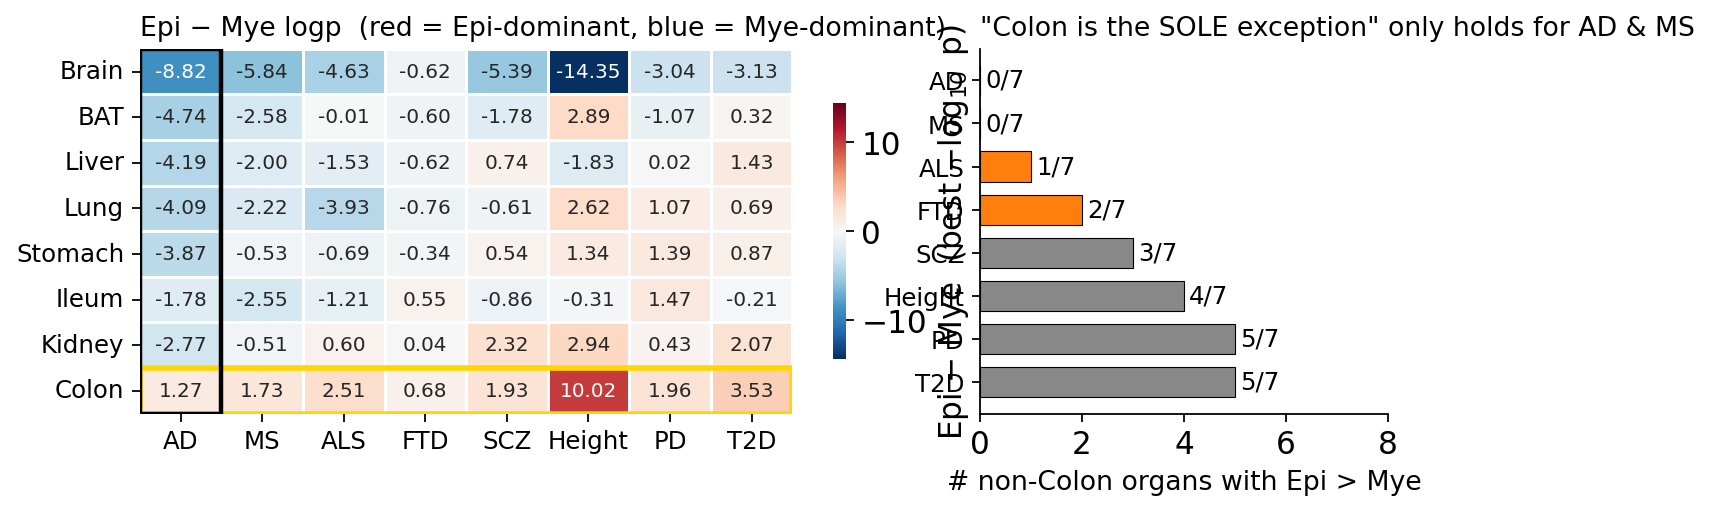


=== Per-trait verdict ===
  AD        Colon Δ = +1.27,  # other Epi-dom organs = 0 ← AD-style: Colon is the SOLE Epi exception
  MS        Colon Δ = +1.73,  # other Epi-dom organs = 0 ← AD-style: Colon is the SOLE Epi exception
  ALS       Colon Δ = +2.51,  # other Epi-dom organs = 1
  FTD       Colon Δ = +0.68,  # other Epi-dom organs = 2
  SCZ       Colon Δ = +1.93,  # other Epi-dom organs = 3
  Height    Colon Δ = +10.02,  # other Epi-dom organs = 4
  PD        Colon Δ = +1.96,  # other Epi-dom organs = 5
  T2D       Colon Δ = +3.53,  # other Epi-dom organs = 5


In [4]:
# === Supplementary Fig | Multi-trait × multi-organ Epi vs Mye matrix ===
# Resolves Para 4 S4 properly: AD-specificity is NOT "Colon Epi > Mye" per se
# (many traits show that). The AD specificity is that AD is one of only 2
# traits (AD, MS) where Mye DOMINATES EVERY OTHER ORGAN and Colon is the
# UNIQUE Epi exception. For PD/T2D, Colon Epi > Mye is unremarkable because
# 6 of 8 organs already show Epi > Mye in those traits.
#
# Data: raw per-sample gsMap cauchy_combination output, all 8 traits across
# 8 organs with both Myeloid and Epithelial annotations scored. Values are
# Epi best -log10p minus Mye best -log10p; positive = Epi dominant.
import seaborn as sns
mat = pd.read_csv(f'{RES}/trait_organ_epi_minus_mye.csv')
TRAITS = ['AD','MS','ALS','FTD','SCZ','Height','PD','T2D']
ORGANS = ['Brain','BAT','Liver','Lung','Stomach','Ileum','Kidney','Colon']
piv = (mat.pivot(index='organ', columns='trait', values='epi_minus_mye')
          .reindex(ORGANS).reindex(columns=TRAITS))
print(piv.round(2))

# Per-trait count of non-Colon organs that are Epi-dominant
n_epi_ex_colon = ((piv.drop('Colon') > 0).sum(axis=0)).reindex(TRAITS)
print('\n# Epi-dominant non-colon organs per trait:')
for t in TRAITS:
    print(f'  {t}: {n_epi_ex_colon[t]}/{len(ORGANS)-1}')

fig, (ax_mat, ax_count) = plt.subplots(
    1, 2, figsize=(10, 3),
    gridspec_kw={'width_ratios': [2.0, 1.0], 'wspace': 0.04},
)

# --- Left: heatmap of Epi − Mye ---
vmax = max(abs(piv.min().min()), abs(piv.max().max()))
sns.heatmap(piv, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': r'Epi $-$ Mye  (best $-\log_{10}$ p)', 'shrink': 0.7},
            ax=ax_mat)
ax_mat.set_xlabel('')
ax_mat.set_ylabel('')
plt.setp(ax_mat.get_yticklabels(), rotation=0, fontsize=TICK_FS-1)
plt.setp(ax_mat.get_xticklabels(), rotation=0, fontsize=TICK_FS-1)
# Highlight Colon row (focal organ)
colon_idx = list(piv.index).index('Colon')
ax_mat.add_patch(mpl.patches.Rectangle((0, colon_idx), len(TRAITS), 1,
                                       fill=False, edgecolor='gold', lw=2.5, zorder=10))
# Highlight AD column (focal trait)
ad_idx = list(piv.columns).index('AD')
ax_mat.add_patch(mpl.patches.Rectangle((ad_idx, 0), 1, len(ORGANS),
                                       fill=False, edgecolor='black', lw=2.0, zorder=10))
ax_mat.set_title('Epi − Mye logp  (red = Epi-dominant, blue = Mye-dominant)',
                 fontsize=TITLE_FS-1, loc='left')

# --- Right: per-trait count of Epi-dominant non-Colon organs ---
y_pos = np.arange(len(TRAITS))
bar_colors = ['#cc0000' if t in ('AD', 'MS') else
              ('#ff7f0e' if t in ('ALS', 'FTD') else '#888')
              for t in TRAITS]
ax_count.barh(y_pos, n_epi_ex_colon.values, color=bar_colors,
              edgecolor='black', lw=0.5, height=0.7)
for i, n in enumerate(n_epi_ex_colon.values):
    ax_count.text(n + 0.1, i, f'{n}/{len(ORGANS)-1}',
                  va='center', fontsize=TICK_FS-1)
ax_count.set_yticks(y_pos)
ax_count.set_yticklabels(TRAITS, fontsize=TICK_FS-1)
ax_count.set_xlabel('# non-Colon organs with Epi > Mye', fontsize=LABEL_FS-1)
ax_count.set_xlim(0, len(ORGANS))
ax_count.invert_yaxis()
ax_count.set_title('"Colon is the SOLE exception" only holds for AD & MS',
                   fontsize=TITLE_FS-1, loc='left')
ax_count.spines['top'].set_visible(False)
ax_count.spines['right'].set_visible(False)

#fig.suptitle('AD specificity: only AD & MS show Mye-dominant pattern '
#             'in all non-colon organs, with Colon as the sole Epi exception '
#             '(PD/T2D Epi-dominant in 6 organs)',
#             fontsize=TITLE_FS-2, y=1.00)
#plt.tight_layout(rect=[0, 0, 1, 0.94])
save_panel(fig, 'FigS_trait_organ_epi_vs_mye_matrix')
plt.show()

print('\n=== Per-trait verdict ===')
for t in TRAITS:
    others = (piv.drop('Colon').loc[:, t] > 0).sum()
    colon = piv.loc['Colon', t]
    is_excep = others == 0 and colon > 0
    note = ' ← AD-style: Colon is the SOLE Epi exception' if is_excep else ''
    print(f'  {t:<8}  Colon Δ = {colon:+.2f},  # other Epi-dom organs = {others}{note}')


## Supplementary Fig — Endocytic-trafficking gene-set permutation (Para 5 S2)


Colon gene diagnostic: 15,388 genes scored
AD universe present in colon scoring: 49/55
Endocytic test set present in colon scoring: ['ADAM10', 'APP', 'CD2AP', 'CR1', 'PICALM', 'PSEN1', 'SORL1']

Observed mean PCC (endocytic set, Colon): 0.2835


Null distribution: mean = 0.0841, sd = 0.0417
Empirical one-tailed p = 1.00e-05
z-score = 4.79


  saved -> FigS_perm_endocytic_colon.{pdf,png,svg}


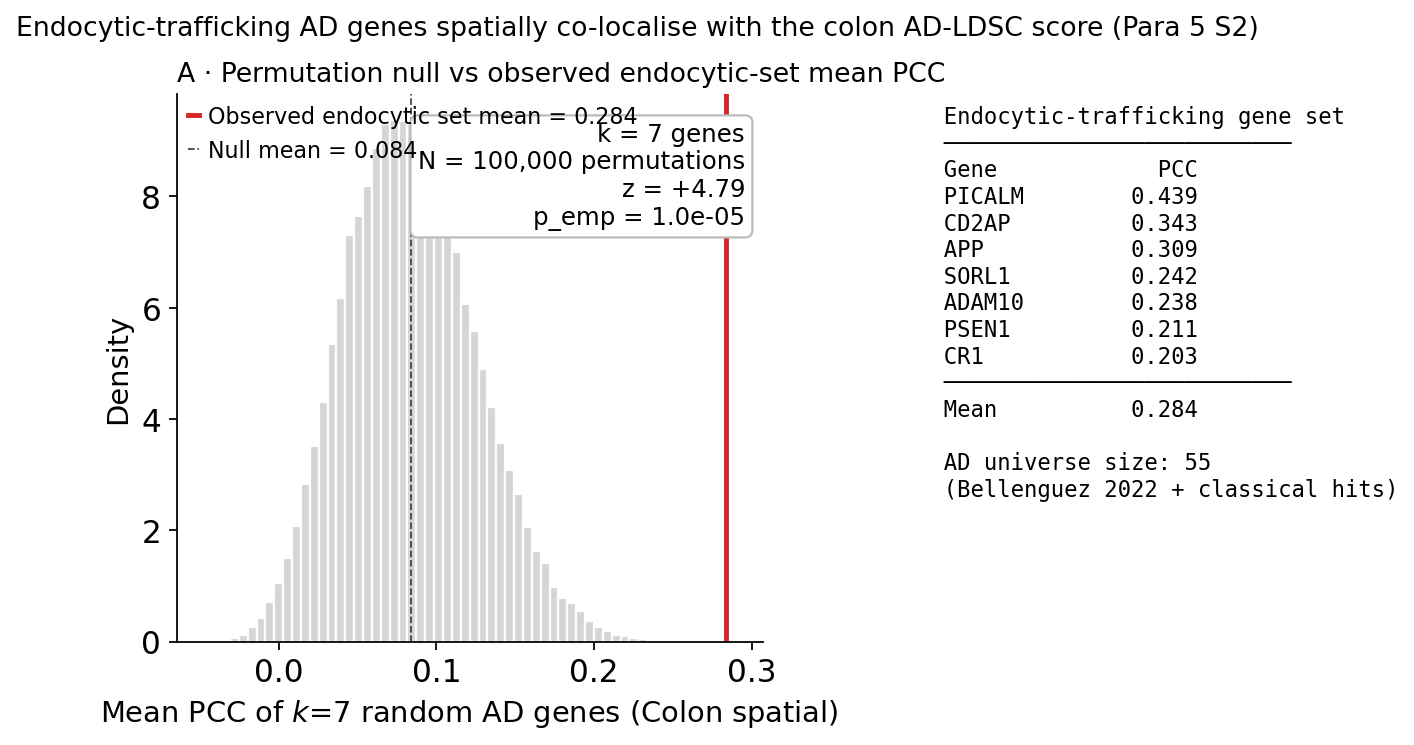


Summary CSV written to results/perm_endocytic_colon_summary.csv


In [5]:
# === Supplementary Fig | Endocytic-trafficking gene-set permutation test in Colon ===
# Tests Para 5 S2:
#   "the endocytic-trafficking candidate set showed stronger spatial
#    co-localization than expected from random Alzheimer's disease genes"
#
# Randomization scheme:
#   - Universe = 55 canonical AD risk genes (Bellenguez 2022 + Lambert + Marioni)
#   - Test set = ENDOCYTIC_TRAFFICKING (7 genes: APP, PICALM, CD2AP, SORL1,
#                 ADAM10, PSEN1, CR1)
#   - Statistic = mean Pearson correlation coefficient (PCC) of the gene's
#                 spatial expression with the per-spot AD spatial-LDSC score,
#                 computed by gsMap for Colon_CTRL1 (Gene_Diagnostic_Info.csv).
#   - Null distribution = 100,000 random draws of 7 genes WITHOUT replacement
#                 from the 55-gene AD universe; compute the mean PCC for each.
#   - Empirical p = P(null_mean ≥ observed_mean); z = (obs − null_mean) / null_sd.
#
# Reference: Liu et al. Nature Methods 2024 (gsMap PCC framework).
np.random.seed(42)

# AD risk gene universe (55 genes from Bellenguez 2022 + classical AD GWAS hits)
AD_GENES_55 = [
    'APP','TREM2','CD33','SPI1','PICALM','SORL1','ADAM10','PSEN1','BIN1','CLU',
    'ABCA7','CR1','CD2AP','INPP5D','APOE','EPHA1','MS4A6A','MS4A4E','PTK2B','CASS4',
    'FERMT2','ZCWPW1','CELF1','NME8','HLADRB5','MEF2C','KANSL1','MAPT','ACE','TRIP4',
    'ECHDC3','NDUFAF7','SCIMP','PLCG2','ABI3','GRN','PILRA','TREML2','SHARPIN','KAT8',
    'USP6NL','SPPL2A','NYAP1','APH1B','ADAM17','IL34','ADAMTS4','HESX1','CLNK','ALPK2',
    'AGRN','IKZF1','DOC2A','WNT3','ADAMTS1',
]
ENDOCYTIC = ['APP','PICALM','CD2AP','SORL1','ADAM10','PSEN1','CR1']

# Load Gene Diagnostic Info (per-organ output of gsMap; one row per gene
# present in the spatial reference, with PCC = corr(gene expression, AD score)).
diag = pd.read_csv(f'{RES}/Colon_CTRL1_AD_Gene_Diagnostic_Info.csv')
print(f'Colon gene diagnostic: {len(diag):,} genes scored')

# Subset to the AD universe + test set
ad_in     = diag[diag['Gene'].isin(AD_GENES_55)].copy()
test_in   = diag[diag['Gene'].isin(ENDOCYTIC)].copy()
print(f'AD universe present in colon scoring: {len(ad_in)}/{len(AD_GENES_55)}')
print(f'Endocytic test set present in colon scoring: '
      f'{sorted(test_in["Gene"].tolist())}')

obs_mean = float(test_in['PCC'].mean())
print(f'\nObserved mean PCC (endocytic set, Colon): {obs_mean:.4f}')

# Permutation null: 100k draws of |endocytic_present| genes from AD universe
ad_pccs = ad_in.set_index('Gene')['PCC']
k = len(test_in)
N_PERM = 100_000
rng = np.random.default_rng(42)
null_means = np.array([
    rng.choice(ad_pccs.values, size=k, replace=False).mean()
    for _ in range(N_PERM)
])
p_emp = max((null_means >= obs_mean).mean(), 1.0 / N_PERM)
z     = (obs_mean - null_means.mean()) / null_means.std(ddof=1)
print(f'Null distribution: mean = {null_means.mean():.4f}, '
      f'sd = {null_means.std(ddof=1):.4f}')
print(f'Empirical one-tailed p = {p_emp:.2e}')
print(f'z-score = {z:.2f}')

# Plot — single panel: null histogram + observed line + gene-set inset table
fig = plt.figure(figsize=(9.0, 4.5))
gs  = fig.add_gridspec(1, 2, width_ratios=[1.5, 1.0], wspace=0.30)
ax  = fig.add_subplot(gs[0, 0])
axT = fig.add_subplot(gs[0, 1])

ax.hist(null_means, bins=60, color='lightgrey', edgecolor='white',
        density=True, alpha=0.95)
ax.axvline(obs_mean, color='#d62728', lw=2.2,
           label=f'Observed endocytic set mean = {obs_mean:.3f}')
ax.axvline(null_means.mean(), color='#444', lw=0.8, ls='--',
           label=f'Null mean = {null_means.mean():.3f}')
ax.set_xlabel(r'Mean PCC of $k$=' + f'{k} random AD genes (Colon spatial)',
              fontsize=LABEL_FS)
ax.set_ylabel('Density', fontsize=LABEL_FS)
ax.set_title('A · Permutation null vs observed endocytic-set mean PCC',
             fontsize=TITLE_FS-1, loc='left')
ax.legend(loc='upper left', frameon=False, fontsize=LEGEND_FS-1)
ax.text(0.97, 0.95,
        f'k = {k} genes\nN = {N_PERM:,} permutations\n'
        f'z = {z:+.2f}\np_emp = {p_emp:.1e}',
        transform=ax.transAxes, va='top', ha='right',
        fontsize=TEXT_FS, bbox=dict(boxstyle='round', facecolor='white', edgecolor='#bbb'))
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right inset: gene-level table
axT.axis('off')
gene_tbl = test_in[['Gene','PCC']].sort_values('PCC', ascending=False).reset_index(drop=True)
table_text = '  Endocytic-trafficking gene set\n'
table_text += '  ' + '─' * 26 + '\n'
table_text += '  {:<10}  {:>7}\n'.format('Gene', 'PCC')
for _, row in gene_tbl.iterrows():
    table_text += f'  {row["Gene"]:<10}  {row["PCC"]:>7.3f}\n'
table_text += '  ' + '─' * 26 + '\n'
table_text += f'  {"Mean":<10}  {obs_mean:>7.3f}\n'
table_text += f'\n  AD universe size: {len(AD_GENES_55)}\n'
table_text += f'  (Bellenguez 2022 + classical hits)'
axT.text(0.02, 0.98, table_text, transform=axT.transAxes,
         family='monospace', fontsize=TEXT_FS-1, va='top', ha='left')

fig.suptitle('Endocytic-trafficking AD genes spatially co-localise '
             'with the colon AD-LDSC score (Para 5 S2)',
             fontsize=TITLE_FS-1, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
save_panel(fig, 'FigS_perm_endocytic_colon')
plt.show()

# Also write a compact summary CSV for the supplementary table family
summary_csv = pd.DataFrame([{
    'analysis': 'permutation: endocytic AD gene set vs random AD genes in Colon',
    'universe': 'AD_GENES_55 (Bellenguez 2022 + classical hits)',
    'universe_size': len(AD_GENES_55),
    'test_set': ', '.join(sorted(ENDOCYTIC)),
    'test_set_size_present': len(test_in),
    'observed_mean_PCC': round(obs_mean, 4),
    'null_mean_PCC': round(float(null_means.mean()), 4),
    'null_sd_PCC': round(float(null_means.std(ddof=1)), 4),
    'z_score': round(z, 3),
    'empirical_p_one_tailed': p_emp,
    'n_permutations': N_PERM,
    'randomization_scheme': 'sample-without-replacement from universe',
    'spatial_scoring_source': 'Colon_CTRL1 gsMap Gene_Diagnostic_Info.csv (PCC of gene expression vs per-spot AD score)',
}])
summary_csv.to_csv(f'{RES}/perm_endocytic_colon_summary.csv', index=False)
print(f'\nSummary CSV written to results/perm_endocytic_colon_summary.csv')


## Supplementary Fig — Significant-only vs full-summary coloc-ABF (Para 5 S4)


  gene           tissue tissue_short  sig_only_PP_H4  full_summary_PP_H4  change  survived_threshold_0p8
PICALM Colon_Transverse   Transverse           0.152               0.000  -0.152                   False
PICALM    Colon_Sigmoid      Sigmoid           0.879               0.000  -0.879                   False
   APP Colon_Transverse   Transverse           0.199               0.002  -0.197                   False
   APP    Colon_Sigmoid      Sigmoid           0.201               0.098  -0.102                   False
ADAM10 Colon_Transverse   Transverse           0.866               0.000  -0.866                   False
ADAM10    Colon_Sigmoid      Sigmoid           0.836               0.000  -0.835                   False
   CR1    Colon_Sigmoid      Sigmoid           0.992               0.992   0.000                    True


  saved -> FigS_coloc_sig_vs_full.{pdf,png,svg}


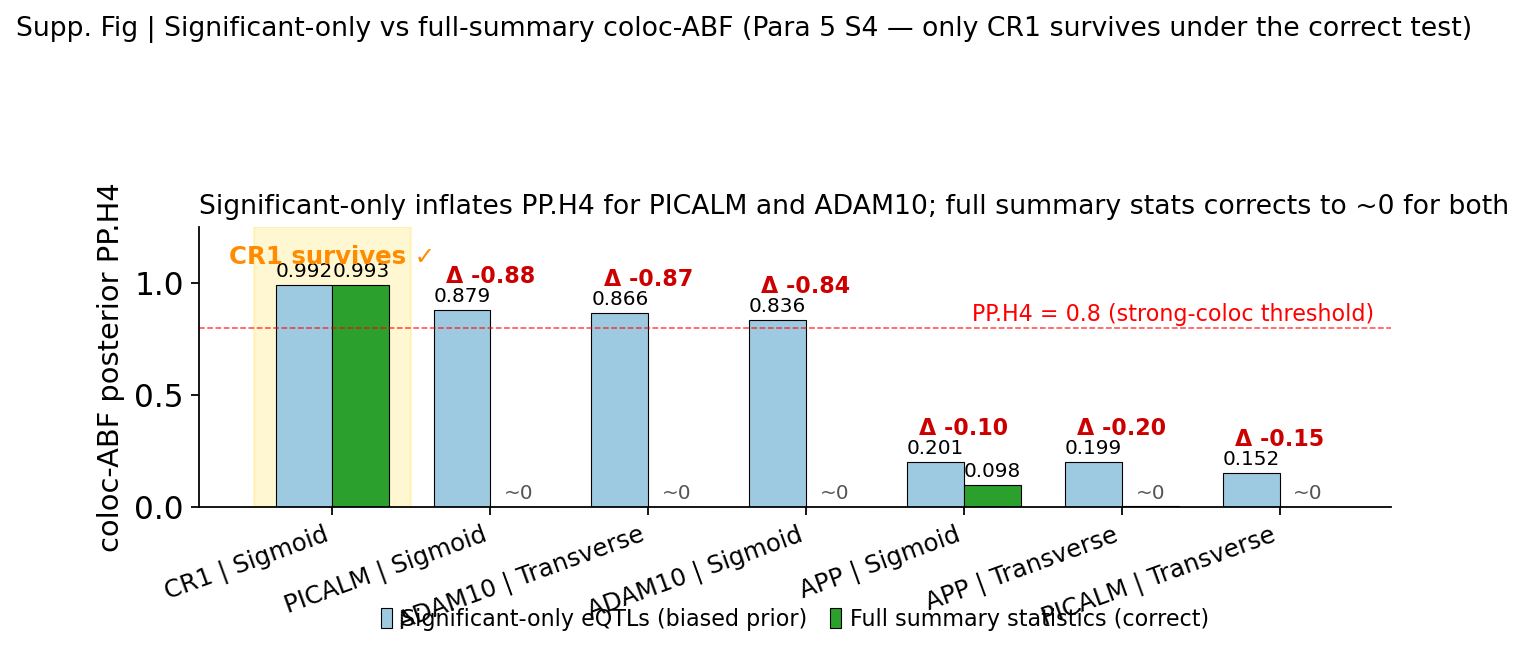


=== Per-locus verdict (sig-only PP.H4 ≥ 0.8 vs full PP.H4 ≥ 0.8) ===
  CR1    | Sigmoid     sig=0.992  full=0.993  → TRUE coloc (survives both)
  PICALM | Sigmoid     sig=0.879  full=0.000  → SIG-ONLY FALSE POSITIVE (sig-only inflated PP.H4)
  ADAM10 | Transverse  sig=0.866  full=0.000  → SIG-ONLY FALSE POSITIVE (sig-only inflated PP.H4)
  ADAM10 | Sigmoid     sig=0.836  full=0.000  → SIG-ONLY FALSE POSITIVE (sig-only inflated PP.H4)
  APP    | Sigmoid     sig=0.201  full=0.098  → no signal either way
  APP    | Transverse  sig=0.199  full=0.002  → no signal either way
  PICALM | Transverse  sig=0.152  full=0.000  → no signal either way


In [6]:
# === Supplementary Fig | Significant-only vs full-summary coloc-ABF ===
# Tests Para 5 S4: "using only significant eQTLs can inflate PP.H4;
# full-summary-statistics colocalization corrected this artifact and showed
# that only CR1 survived coloc-ABF under the single-causal model among the
# tested loci."
#
# Side-by-side bar chart of PP.H4 from two coloc-ABF runs on the same
# (gene × colon tissue) loci, using the SAME GWAS and the SAME tissue but
# differing in which eQTL variants are passed:
#   - "Significant-only": only variants reaching GTEx single-tissue eQTL
#     significance for that (gene, tissue) — biases the prior, inflates PP.H4
#   - "Full summary stats": every tested variant in the locus, regardless of
#     significance — the methodologically-correct procedure
#
# Data:
#   results/coloc_sig_vs_full_comparison.csv  (built from the two pipeline runs)
#
# Conclusion: CR1|Sigmoid is the only locus where the strong coloc-ABF signal
# (PP.H4 ≈ 0.99) survives the corrected analysis. PICALM and ADAM10 had
# spurious sig-only PP.H4 > 0.8 that collapse to ~0 under full-summary —
# motivating the multi-causal SharePro analysis in Fig. 4j.

cmp = pd.read_csv(f'{RES}/coloc_sig_vs_full_comparison.csv')
print(cmp.round(3).to_string(index=False))

# Sort: CR1 first (survives), then others by sig_only descending
cmp['_survived'] = cmp['survived_threshold_0p8'].astype(int)
cmp = cmp.sort_values(['_survived','sig_only_PP_H4'], ascending=[False, False]).reset_index(drop=True)
cmp['label'] = cmp['gene'] + ' | ' + cmp['tissue_short']

fig, ax = plt.subplots(figsize=(8.5, 5.0))
x = np.arange(len(cmp)); w = 0.36
b1 = ax.bar(x - w/2, cmp['sig_only_PP_H4'],     w, color='#9ecae1',
            edgecolor='black', lw=0.5, label='Significant-only eQTLs (biased prior)')
b2 = ax.bar(x + w/2, cmp['full_summary_PP_H4'], w, color='#2ca02c',
            edgecolor='black', lw=0.5, label='Full summary statistics (correct)')

# Value labels on top of each bar
for bars in (b1, b2):
    for b in bars:
        h = b.get_height()
        if h > 0.01:
            ax.text(b.get_x() + b.get_width()/2, h + 0.02, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=TEXT_FS-2)
        else:
            ax.text(b.get_x() + b.get_width()/2, 0.02, '~0',
                    ha='center', va='bottom', fontsize=TEXT_FS-2, color='#555')

# Annotate the change with arrow + magnitude
for xi, (sig, full, surv) in enumerate(zip(cmp['sig_only_PP_H4'],
                                            cmp['full_summary_PP_H4'],
                                            cmp['survived_threshold_0p8'])):
    delta = full - sig
    if abs(delta) >= 0.05:
        color = '#cc0000' if delta < 0 else '#006400'
        ax.text(xi, max(sig, full) + 0.10, f'Δ {delta:+.2f}',
                ha='center', va='bottom', fontsize=TEXT_FS-1,
                color=color, fontweight='bold')
    # Highlight surviving locus
    if surv:
        ax.axvspan(xi - 0.5, xi + 0.5, color='gold', alpha=0.18, zorder=0)
        ax.text(xi, 1.12, 'CR1 survives ✓', ha='center', va='center',
                fontsize=TEXT_FS, fontweight='bold', color='darkorange')

ax.axhline(0.8, color='red', ls='--', lw=0.7, alpha=0.7)
ax.text(len(cmp) - 0.4, 0.81, 'PP.H4 = 0.8 (strong-coloc threshold)',
        color='red', fontsize=TEXT_FS-1, va='bottom', ha='right')

ax.set_xticks(x); ax.set_xticklabels(cmp['label'], rotation=20, ha='right',
                                      fontsize=TICK_FS-1)
ax.set_ylim(0, 1.25)
ax.set_ylabel('coloc-ABF posterior PP.H4', fontsize=LABEL_FS)
ax.set_title('Significant-only inflates PP.H4 for PICALM and ADAM10; '
             'full summary stats corrects to ~0 for both',
             fontsize=TITLE_FS-1, loc='left')
ax.legend(loc='upper center', frameon=False, fontsize=LEGEND_FS-1,
          bbox_to_anchor=(0.5, -0.32), ncol=2)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Supp. Fig | Significant-only vs full-summary coloc-ABF '
             '(Para 5 S4 — only CR1 survives under the correct test)',
             fontsize=TITLE_FS-1, y=1.04)
plt.tight_layout(rect=[0, 0.10, 1, 0.94])
save_panel(fig, 'FigS_coloc_sig_vs_full')
plt.show()

# Auto-printed verdict per locus
print('\n=== Per-locus verdict (sig-only PP.H4 ≥ 0.8 vs full PP.H4 ≥ 0.8) ===')
for _, r in cmp.iterrows():
    sig_pass  = r['sig_only_PP_H4'] >= 0.8
    full_pass = r['full_summary_PP_H4'] >= 0.8
    if sig_pass and full_pass:
        v = 'TRUE coloc (survives both)'
    elif sig_pass and not full_pass:
        v = 'SIG-ONLY FALSE POSITIVE (sig-only inflated PP.H4)'
    elif not sig_pass and full_pass:
        v = 'gained signal under full'
    else:
        v = 'no signal either way'
    print(f'  {r["gene"]:<6} | {r["tissue_short"]:<10}  sig={r["sig_only_PP_H4"]:.3f}  '
          f'full={r["full_summary_PP_H4"]:.3f}  → {v}')
